  age   sex        ward   wbc   rbc    hb   hct   mcv    plt  mono   bun  \
0  76  male         CCU   NaN   NaN   NaN   NaN   NaN    NaN   NaN  55.0   
1  76  male         CCU   NaN   NaN   NaN   NaN   NaN    NaN   NaN   NaN   
2  70  male    داخلي يك   NaN   NaN   NaN   NaN   NaN    NaN   NaN  16.0   
3  70  male    داخلي يك  11.4  4.77  13.8  42.6  89.3  127.0   4.0   NaN   
4  66  male   روانپزشكي  10.6  4.90  14.1  46.6  95.1  169.0   3.8   NaN   

      na    k  
0  135.0  4.0  
1    NaN  NaN  
2  143.0  4.1  
3    NaN  NaN  
4    NaN  NaN  
Index(['age', 'sex', 'ward', 'wbc', 'rbc', 'hb', 'hct', 'mcv', 'plt', 'mono',
       'bun', 'na', 'k'],
      dtype='object')
age       0
sex       0
ward      0
wbc     636
rbc     636
hb      636
hct     636
mcv     636
plt     636
mono    747
bun     616
na      594
k       596
dtype: int64
(396, 13)
age       0
sex       0
ward      0
wbc       0
rbc       0
hb        0
hct       0
mcv       0
plt       0
mono     98
bun     396
na      39

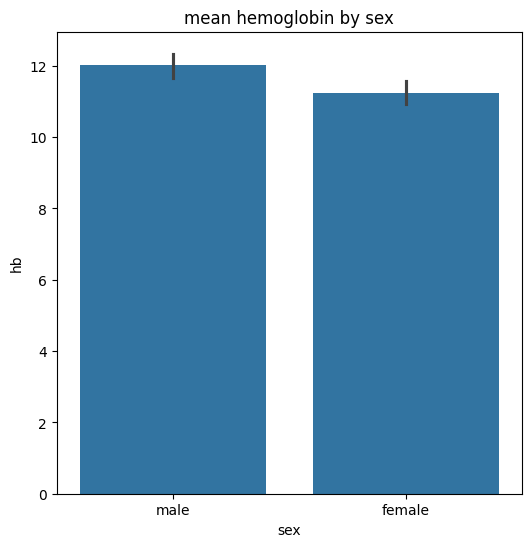

correlation between ward and hemoglobin: ward
  (SICU (ICU1        10.760000
  MICU1               9.650000
 ICU جنرال           10.247368
 ارتوپدي             12.060000
 اورژانس بستري       12.484211
 جراحي عمومي  يك     10.811765
 خون و آنكولوژي      10.540909
 داخلي دو            11.110714
 داخلي يك            10.606061
 زنان                11.250000
 عفوني               10.321429
 نفرولوژي            10.306250
ICU اورژانس          10.622222
آزمايشگاه  مركزي     13.575325
Name: hb, dtype: float64


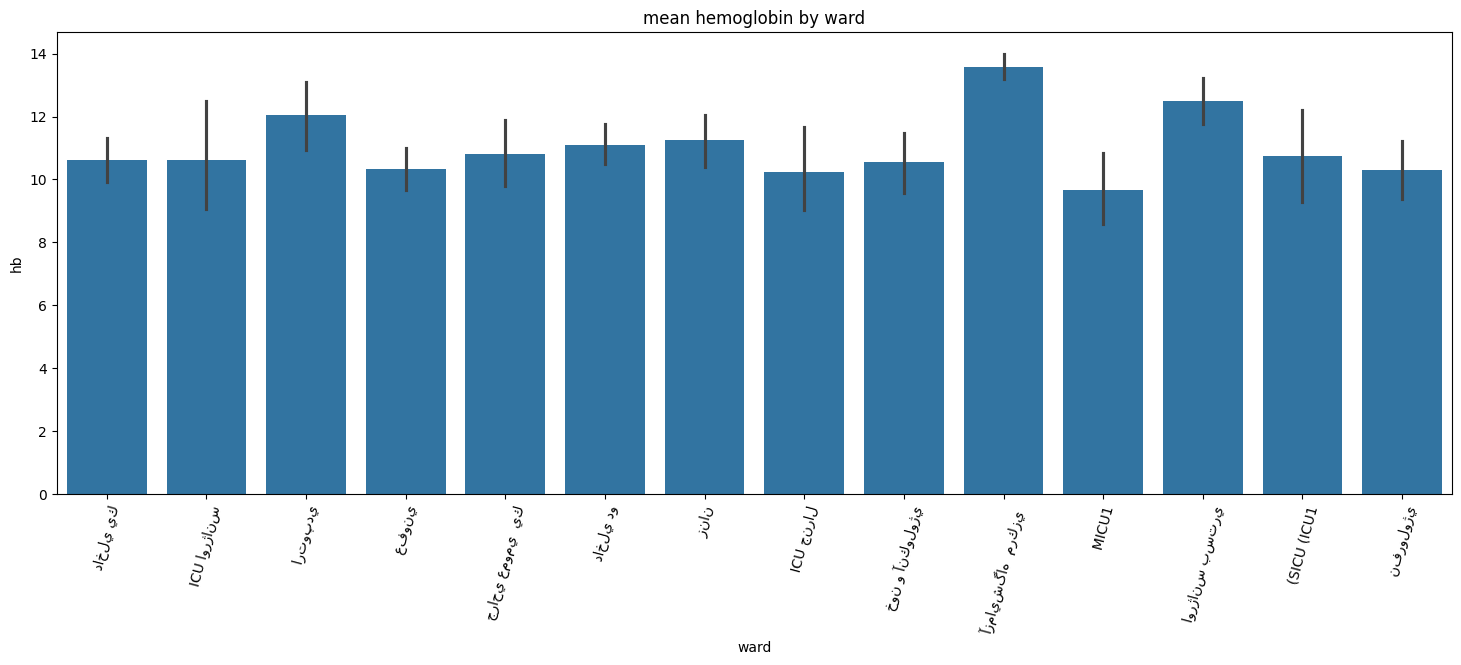

اcorrelation between hct, hb: 0.9658228671192449


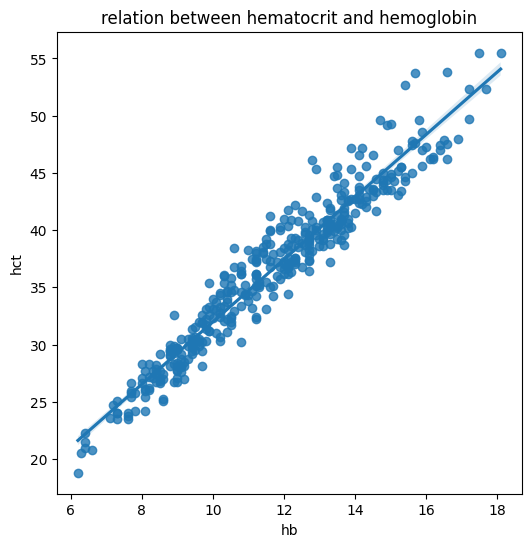

In [1]:
import pandas as pd 
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
df=pd.read_csv("CBC.csv",encoding="cp1256",sep=";",usecols=["سن بيمار","جنسيت","محل درخواست",
"CBC,Diff-CBC & Diff-W.B.C","CBC,Diff-CBC & Diff-R.B.C","CBC,Diff-CBC & Diff-Hb",
"CBC,Diff-CBC & Diff-Hct","CBC,Diff-CBC & Diff-Platelet","CBC,Diff-CBC & Diff-M.C.V",
"CBC,Diff-Diff Result-Monocyte","BUN--B.U.N","Na--Serum Na","K--Serum K"])
df.rename(columns={"سن بيمار":"age","CBC,Diff-CBC & Diff-W.B.C":"wbc",
"CBC,Diff-CBC & Diff-R.B.C":"rbc","CBC,Diff-CBC & Diff-Hb":"hb",
"CBC,Diff-CBC & Diff-Hct":"hct","جنسيت":"sex","CBC,Diff-CBC & Diff-Platelet":"plt",
"CBC,Diff-CBC & Diff-M.C.V":"mcv","CBC,Diff-Diff Result-Monocyte":"mono",
"محل درخواست":"ward","BUN--B.U.N":"bun",
"Na--Serum Na":"na","K--Serum K":"k"},inplace=True)

df["age"]=df["age"].str.replace("ساله","").str.replace("روزه","").str.replace(" ","")
df["sex"]=df["sex"].str.replace("مرد","male").str.replace("زن","female")
df["ward"]=df["ward"].str.replace("بخش","")
print(df.head())
print(df.columns)
print(df.isnull().sum())

cols=['wbc', 'rbc', 'hb', 'hct', 'mcv', 'plt']
for w in cols:
    df[w]=pd.to_numeric(df[w],errors="coerce")
df=df.dropna(subset=['wbc', 'rbc', 'hb', 'hct', 'mcv', 'plt'])

def remove_outlier(df, col_name):
    q1=df[col_name].quantile(0.25)
    q3=df[col_name].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    return df[(df[col_name]>= lower)&(df[col_name]<=upper)]
for w in cols:
    df = df[df[w] != 0]
    df = remove_outlier(df, w)
print(df.shape)
print(df.isnull().sum())


hb_sex=df.groupby("sex")["hb"].mean()
print(hb_sex)
plt.figure(figsize=(6,6))
sns.barplot(x="sex",y="hb",data=df)
plt.title("mean hemoglobin by sex")
plt.show()

ward_count=df["ward"].value_counts()
ward_count=ward_count[ward_count>7].index
df2=df[df["ward"].isin(ward_count)]
hb_ward=df2.groupby("ward")["hb"].mean()
print("correlation between ward and hemoglobin:",hb_ward)
plt.figure(figsize=(18,6))
sns.barplot(x="ward",y="hb",data=df2)
plt.xticks(rotation=75)
plt.title("mean hemoglobin by ward")
plt.show()

print("اcorrelation between hct, hb:",df["hct"].corr(df["hb"]))
plt.figure(figsize=(6,6))
sns.regplot(x="hb",y="hct",data=df)
plt.title("relation between hematocrit and hemoglobin")
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=17d9599a-e07d-4c50-b1b1-f0833538d301' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>